# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [5]:
#seu código aqui

#### a) Carregamento da base

In [2]:
X_test = pd.read_csv('X_test.csv', delimiter=',')
X_train = pd.read_csv('X_train_balanced.csv', delimiter=',')
y_test = pd.read_csv('y_test.csv', delimiter=',')
y_train = pd.read_csv('y_train_balanced.csv', delimiter=',')

#### b) Conferir o número de linhas e colunas de X e y

In [6]:
X_test

,Idade,Salario_Mensal,Numero_Filhos,Genero_encoded,Estado_Civil_encoded,Tipo_Residencia_encoded,Educacao_Diploma de Bacharel,Educacao_Diploma de Ensino Médio,Educacao_Diploma de Mestrado,Educacao_Diploma de Nível Técnico,Educacao_Doutorado,Score_Credito_Alto,Score_Credito_Baixo,Score_Credito_Médio
0,25,55000.0,0,0,1,0,True,False,False,False,False,False,False,True
1,48,87500.0,1,0,0,1,False,False,False,False,True,True,False,False
2,26,55000.0,1,0,0,1,True,False,False,False,False,False,False,True
3,39,62500.0,2,0,0,1,True,False,False,False,False,True,False,False
4,35,90000.0,1,0,0,1,False,False,False,False,True,True,False,False
5,25,55000.0,0,0,1,0,True,False,False,False,False,False,False,True
6,48,82500.0,1,0,0,1,False,False,False,False,True,True,False,False
7,48,82500.0,1,0,0,1,False,False,False,False,True,True,False,False
8,36,95000.0,2,0,0,1,False,False,True,False,False,True,False,False
9,37,95000.0,1,0,0,1,False,True,False,False,False,True,False,False


In [7]:
y_test

,Score_Credito
0,Médio
1,Alto
2,Médio
3,Alto
4,Alto
5,Médio
6,Alto
7,Alto
8,Alto
9,Alto


In [8]:
X_train

,Idade,Salario_Mensal,Numero_Filhos,Genero_encoded,Estado_Civil_encoded,Tipo_Residencia_encoded,Educacao_Diploma de Bacharel,Educacao_Diploma de Ensino Médio,Educacao_Diploma de Mestrado,Educacao_Diploma de Nível Técnico,Educacao_Doutorado,Score_Credito_Alto,Score_Credito_Baixo,Score_Credito_Médio
0,26,45000.000000,0,0,1,0,False,False,False,True,False,False,False,True
1,29,27500.000000,0,0,1,0,False,True,False,False,False,False,True,False
2,25,62500.000000,0,0,1,0,True,False,False,False,False,False,False,True
3,29,68000.000000,2,0,0,1,False,False,False,False,True,False,False,True
4,31,65000.000000,0,1,1,0,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,29,43703.466973,0,0,1,0,False,False,False,True,False,False,False,True
248,34,47500.000000,0,1,1,0,False,False,False,True,False,False,False,True
249,30,57500.000000,0,0,1,0,True,False,False,True,False,False,False,True
250,25,60063.547817,0,0,1,0,True,False,False,False,False,False,False,True


In [9]:
y_train

,Score_Credito
0,Médio
1,Baixo
2,Médio
3,Médio
4,Médio
...,...
247,Médio
248,Médio
249,Médio
250,Médio


Como esta base de dados é a mesma utilizada no treinamento anterior com o algoritmo Naive Bayes, observa-se novamente que as bases X_train e X_test contêm variáveis categóricas binárias (*True*/*False*) para Score_Credito_Alto, Score_Credito_Baixo e Score_Credito_Médio, que são derivações diretas da variável alvo (y). Isso caracteriza vazamento de dados (*data leakage*), pois o modelo teria acesso indireto à resposta durante o treinamento.

Para evitar esse problema, essas colunas foram removidas das bases de *features*, garantindo que o modelo seja treinado apenas com informações independentes da variável alvo.

In [3]:
# Exclusão das colunas da base X_train e X_test
colunas_remover = ['Score_Credito_Alto',
                   'Score_Credito_Médio',
                   'Score_Credito_Baixo'
                  ]

X_train = X_train.drop(columns=colunas_remover)
X_test = X_test.drop(columns=colunas_remover)

In [12]:
# Conferindo se as colunas foram exluidas da base X_train
X_train

,Idade,Salario_Mensal,Numero_Filhos,Genero_encoded,Estado_Civil_encoded,Tipo_Residencia_encoded,Educacao_Diploma de Bacharel,Educacao_Diploma de Ensino Médio,Educacao_Diploma de Mestrado,Educacao_Diploma de Nível Técnico,Educacao_Doutorado
0,26,45000.000000,0,0,1,0,False,False,False,True,False
1,29,27500.000000,0,0,1,0,False,True,False,False,False
2,25,62500.000000,0,0,1,0,True,False,False,False,False
3,29,68000.000000,2,0,0,1,False,False,False,False,True
4,31,65000.000000,0,1,1,0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
247,29,43703.466973,0,0,1,0,False,False,False,True,False
248,34,47500.000000,0,1,1,0,False,False,False,True,False
249,30,57500.000000,0,0,1,0,True,False,False,True,False
250,25,60063.547817,0,0,1,0,True,False,False,False,False


In [13]:
# Conferindo se as colunas foram exluidas da base X_test
X_test

,Idade,Salario_Mensal,Numero_Filhos,Genero_encoded,Estado_Civil_encoded,Tipo_Residencia_encoded,Educacao_Diploma de Bacharel,Educacao_Diploma de Ensino Médio,Educacao_Diploma de Mestrado,Educacao_Diploma de Nível Técnico,Educacao_Doutorado
0,25,55000.0,0,0,1,0,True,False,False,False,False
1,48,87500.0,1,0,0,1,False,False,False,False,True
2,26,55000.0,1,0,0,1,True,False,False,False,False
3,39,62500.0,2,0,0,1,True,False,False,False,False
4,35,90000.0,1,0,0,1,False,False,False,False,True
5,25,55000.0,0,0,1,0,True,False,False,False,False
6,48,82500.0,1,0,0,1,False,False,False,False,True
7,48,82500.0,1,0,0,1,False,False,False,False,True
8,36,95000.0,2,0,0,1,False,False,True,False,False
9,37,95000.0,1,0,0,1,False,True,False,False,False


#### c) Verificar o balanceamento de y

In [4]:
# Contar o número de exemplos de cada classe em y_train
train_balance = y_train.value_counts()
print('Balanceamento em y_train:')
print(train_balance)

# Contar o número de exemplos em cada classe de y_test
test_balance = y_test.value_counts()
print('\nBalanceamento em y_test:')
print(test_balance)

Balanceamento em y_train:
Score_Credito
Alto             84
Baixo            84
Médio            84
Name: count, dtype: int64

Balanceamento em y_test:
Score_Credito
Alto             29
Baixo             6
Médio             6
Name: count, dtype: int64


As bases foram tratadas de forma adequada quanto ao balanceamento. A variável y_train está balanceada entre as categorias, o que é fundamental para evitar vieses no treinamento do modelo de Machine Learning.

Já a variável y_test permanece desbalanceada, o que é desejável, pois reflete melhor a distribuição real dos dados e permite avaliar a eficácia do modelo em um cenário mais próximo da realidade.

# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

In [ ]:
#Sua resposta aqui

**PASSO A PASSO**
##### 1) Realizar o tratamento da base de dados, incluindo limpeza, tratamento de valores ausentes e codificação de variáveis categóricas;
##### 2) Realizar o balanceamento dos dados (se necessário) e a separação entre variáveis explicativas (X) e variável alvo (y), além da divisão em conjuntos de treino e teste;
##### 3) Validar a consistência dos dados, garantindo que:
- a variável alvo não esteja presente em X (evitando *data leakage*);
- todas as variáveis estejam devidamente tratadas;
- os conjuntos de treino e teste estejam corretamente alinhados;
##### 4) Treinar o modelo utilizando o algoritmo de Árvore de Decisão na base de treino;
##### 5) Avaliar o desempenho do modelo na base de treino por meio de métricas como acurácia, recall, precisão, F1-score e matriz de confusão;
##### 6) Aplicar o modelo treinado na base de teste;
##### 7) Avaliar o desempenho na base de teste utilizando as mesmas métricas, verificando a capacidade de generalização do modelo;
##### 8) Analisar a importância das variáveis (*feature importance*) para entender quais atributos mais influenciam a decisão do modelo;
##### 9) Aplicar técnicas de ajuste do modelo (como poda da árvore ou tuning de hiperparâmetros) para reduzir *overfitting* e melhorar a performance;
##### 10) Reavaliar o modelo após os ajustes, verificando se houve melhoria nas métricas e alinhamento com os objetivos do projeto.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modelo com os dados de treino.

In [ ]:
#seu código aqui

#### a) Aplicação do algoritmo da árvore de decisão

In [8]:
# Criação de uma instância para o classificador árvore de decisão
arvore_score = DecisionTreeClassifier (criterion = 'gini', random_state = 0)

arvore_score.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

#### b) Análise da acurácia

In [53]:
# Previsão do modelo na base de treino
y_pred_train = arvore_score.predict(X_train)

# Calcular acurácia, relátorio de classificação e matriz de confusão
accuracy = accuracy_score(y_train, y_pred_train)
relatorio = classification_report(y_train, y_pred_train)
conf_matrix = confusion_matrix(y_train, y_pred_train)
print(f'Acurácia: {accuracy}')
print(f'{"-" * 55}')
print('Relátorio de Classificação')
print(relatorio)
print(f'{"-" * 55}')
print(f'Matriz de confusão \n{conf_matrix}')

Acurácia: 1.0
-------------------------------------------------------
Relátorio de Classificação
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00        84
       Baixo       1.00      1.00      1.00        84
       Médio       1.00      1.00      1.00        84

    accuracy                           1.00       252
   macro avg       1.00      1.00      1.00       252
weighted avg       1.00      1.00      1.00       252

-------------------------------------------------------
Matriz de confusão 
[[84  0  0]
 [ 0 84  0]
 [ 0  0 84]]


A acurácia de 100% na base de treinamento indica que o modelo de Árvore de Decisão conseguiu ajustar-se perfeitamente aos dados utilizados no treino. No entanto, esse desempenho pode ser um indicativo de *overfitting*, sugerindo que o modelo pode ter aprendido padrões muito específicos da base de treino, o que pode comprometer sua capacidade de generalização em novos dados.

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [ ]:
#seu código aqui

In [54]:
# Previsão do modelo na base de teste
y_pred_test = arvore_score.predict(X_test)

# Calcular acurácia, relátorio de classificação e matriz de confusão
accuracy = accuracy_score(y_test, y_pred_test)
relatorio = classification_report(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
print(f'Acurácia: {accuracy}')
print(f'{"-" * 55}')
print('Relátorio de Classificação')
print(relatorio)
print(f'{"-" * 55}')
print(f'Matriz de confusão \n{conf_matrix}')

Acurácia: 0.975609756097561
-------------------------------------------------------
Relátorio de Classificação
              precision    recall  f1-score   support

        Alto       1.00      0.97      0.98        29
       Baixo       1.00      1.00      1.00         6
       Médio       0.86      1.00      0.92         6

    accuracy                           0.98        41
   macro avg       0.95      0.99      0.97        41
weighted avg       0.98      0.98      0.98        41

-------------------------------------------------------
Matriz de confusão 
[[28  0  1]
 [ 0  6  0]
 [ 0  0  6]]


Apesar da leve queda na acurácia da base de treino 100% para a de teste 97,5%, o modelo mantém alto desempenho geral, indicando boa capacidade de generalização. Observa-se um leve indício de *overfitting*, comum em árvores de decisão, evidenciado pelo desempenho perfeito no treino. As métricas por classe mostram pequenas variações, com leve redução no recall da classe Alto e menor precisão na classe Médio, sugerindo erros pontuais entre categorias próximas, mas sem comprometer a performance global do modelo.

A análise das matrizes de confusão reforça esse comportamento: enquanto na base de treino o modelo apresenta classificação perfeita em todas as classes, na base de teste observa-se apenas um erro isolado, onde um caso da classe Alto foi classificado incorretamente. Esse padrão indica que os erros são mínimos e não sistemáticos, reforçando a robustez do modelo mesmo diante de novos dados.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

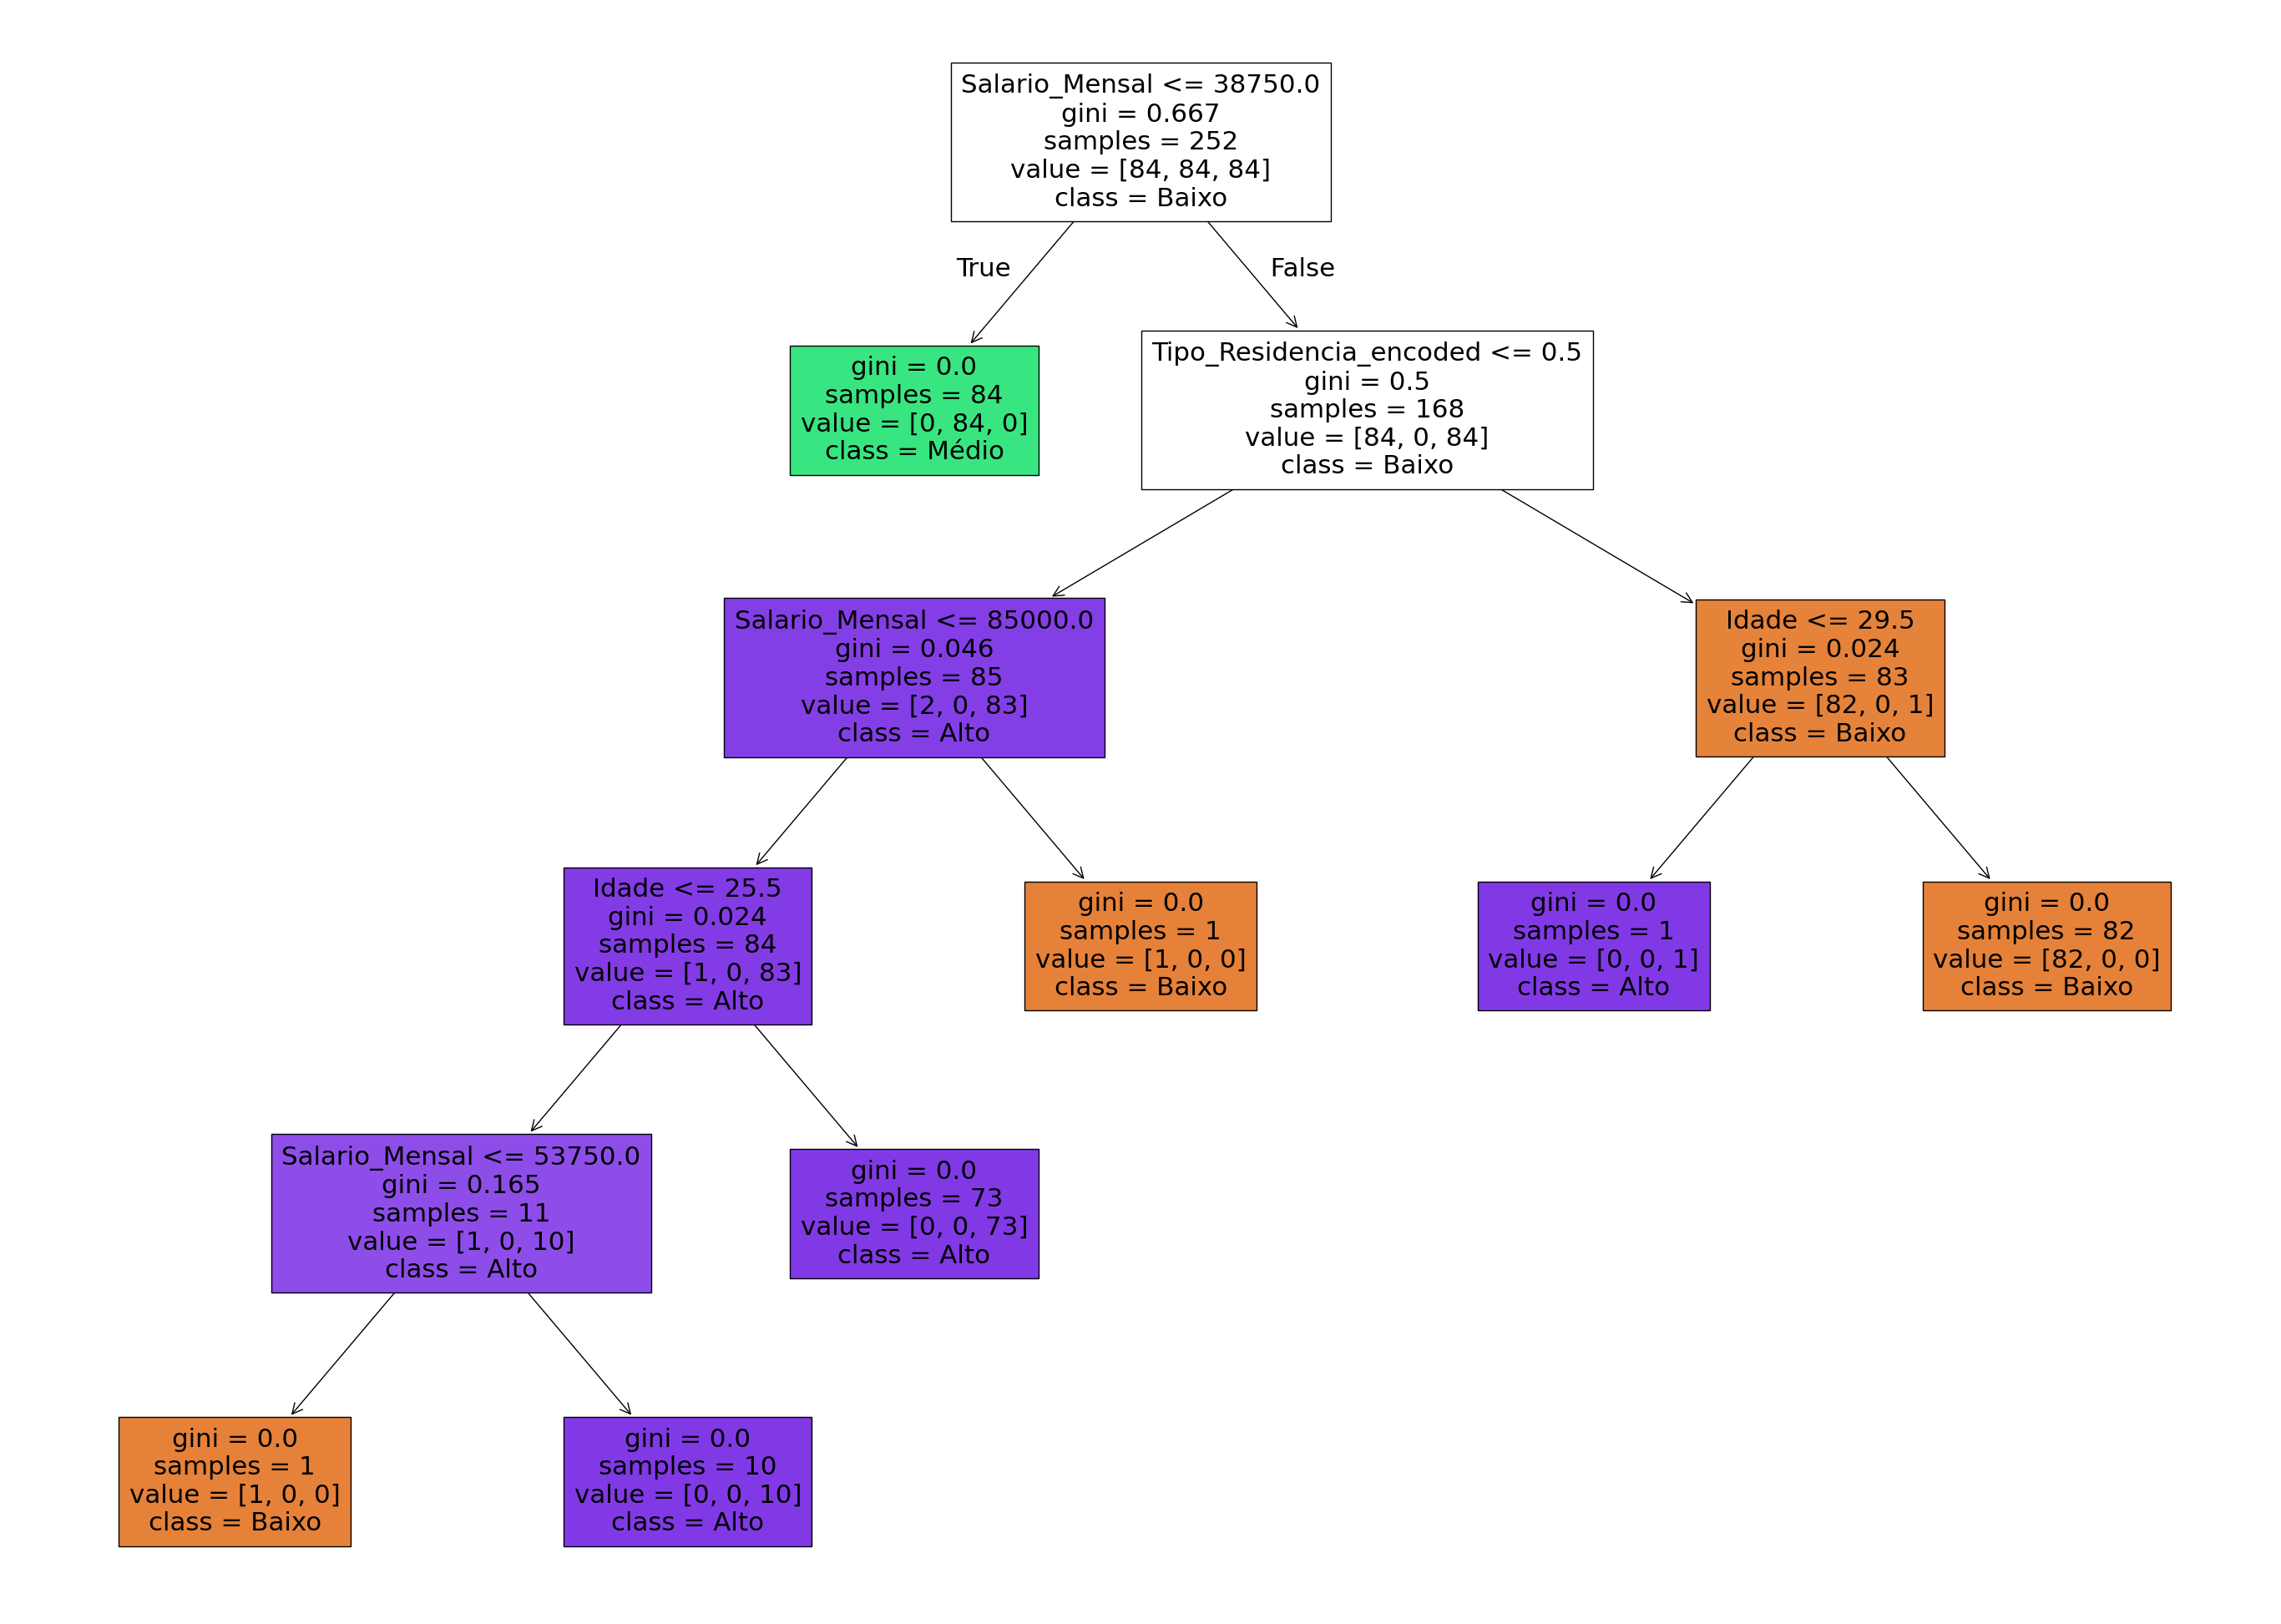

In [16]:
#seu código aqui
# Plotagem da árvore de decisão
plt.figure(figsize=(35, 25))
plot_tree(
    arvore_score, 
    filled=True, 
    feature_names=X_train.columns, 
    class_names=['Baixo', 'Médio', 'Alto']
)
plt.show()

In [19]:
profundidade = arvore_score.get_depth()
print(f"Sim, é possivel fazer uma avaliação visual. A profundidade da árvore é: {profundidade}")

Sim, é possivel fazer uma avaliação visual. A profundidade da árvore é: 5


# 6) Identifique as 2 principais features do modelo.


<function matplotlib.pyplot.show(close=None, block=None)>

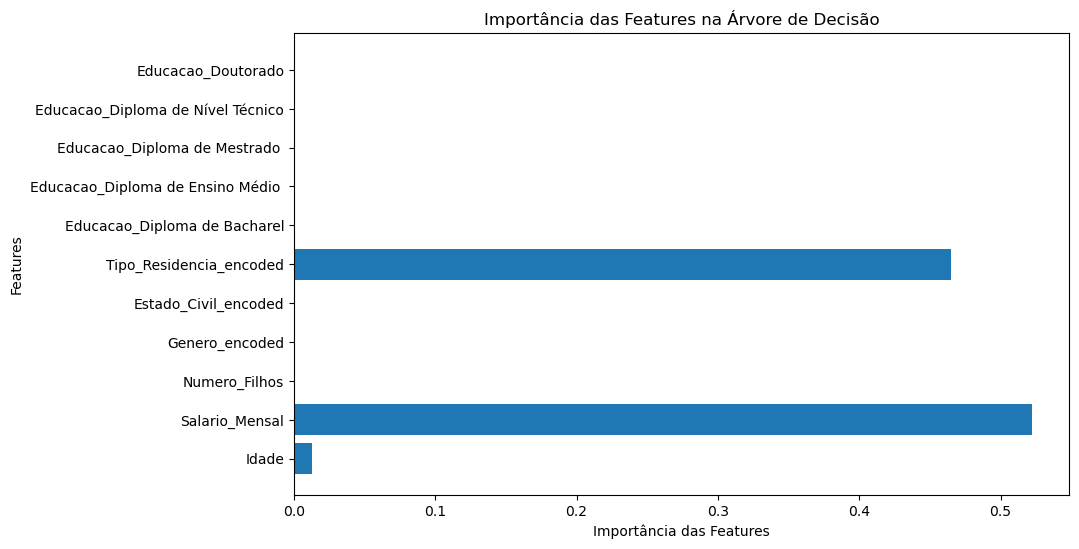

In [20]:
#seu código aqui
# Obtendo a importância das características do modelo da árvore de decisão
importancias_features = arvore_score.feature_importances_

# Obtendo os nomes das características
nomes_features = X_train.columns

# Criando gráfico de barras para visualizar a importância das características
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, importancias_features)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show

As duas principais features identificadas pelo modelo são Tipo_Residencia_encoded e Salario_Mensal.

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [ ]:
#seu código aqui

#### a) Aplicação do algoritmo da árvore de decisão com apenas as 2 princiapis features

In [28]:
# Definição das 2 principais features
X_train_reduzido = X_train[['Tipo_Residencia_encoded', 'Salario_Mensal']]
X_test_reduzido = X_test[['Tipo_Residencia_encoded', 'Salario_Mensal']]

In [29]:
# Refinamento do classificador árvore de decisão
arvore_score_reduzido = DecisionTreeClassifier (criterion = 'gini', random_state = 0)

arvore_score_reduzido.fit(X_train_reduzido, y_train)

DecisionTreeClassifier(random_state=0)

#### b) Aplicação do modelo aos dados de treinamento e avaliação dos resultados

In [55]:
# Previsão do modelo com 2 features na base de treino
previsoes_reduzido = arvore_score_reduzido.predict(X_train_reduzido)

# Calcular acurácia, relátorio de classificação e matriz de confusão
accuracy = accuracy_score(y_train, previsoes_reduzido)
relatorio = classification_report(y_train, previsoes_reduzido)
conf_matrix = confusion_matrix(y_train, previsoes_reduzido)
print(f'Acurácia: {accuracy}')
print(f'{"-" * 55}')
print('Relátorio de Classificação')
print(relatorio)
print(f'{"-" * 55}')
print(f'Matriz de confusão \n{conf_matrix}')

Acurácia: 0.996031746031746
-------------------------------------------------------
Relátorio de Classificação
              precision    recall  f1-score   support

        Alto       0.99      1.00      0.99        84
       Baixo       1.00      1.00      1.00        84
       Médio       1.00      0.99      0.99        84

    accuracy                           1.00       252
   macro avg       1.00      1.00      1.00       252
weighted avg       1.00      1.00      1.00       252

-------------------------------------------------------
Matriz de confusão 
[[84  0  0]
 [ 0 84  0]
 [ 1  0 83]]


Mesmo utilizando apenas as duas principais variáveis, o modelo de Árvore de Decisão apresentou desempenho quase perfeito na base de treino, com acurácia de 99,6% e métricas de precisão, recall e F1-score próximas de 1,00 em todas as classes. Isso evidencia que essas features possuem alto poder discriminatório, sendo capazes de explicar praticamente todo o comportamento do score de crédito. As pequenas variações observadas, como a leve redução no recall da classe Médio, são pontuais e não impactam significativamente o desempenho geral.

A matriz de confusão reforça esse resultado, evidenciando apenas um erro isolado, onde um registro da classe Médio foi classificado incorretamente como Alto, enquanto as demais classes foram perfeitamente classificadas. Esse padrão indica que os erros são mínimos e concentrados em casos específicos, sem comprometer a capacidade geral do modelo.

Dessa forma, o resultado demonstra que um modelo mais simples, com menor número de variáveis, pode manter alta performance, além de favorecer a interpretabilidade.

#### c) Aplicação do modelo aos dados de teste e avaliação dos resultados

In [56]:
# Previsão do modelo com 2 features na base de teste
previsoes_reduzido = arvore_score_reduzido.predict(X_test_reduzido)

# Calcular acurácia, relátorio de classificação e matriz de confusão
accuracy = accuracy_score(y_test, previsoes_reduzido)
relatorio = classification_report(y_test, previsoes_reduzido)
conf_matrix = confusion_matrix(y_test, previsoes_reduzido)
print(f'Acurácia: {accuracy}')
print(f'{"-" * 55}')
print('Relátorio de Classificação')
print(relatorio)
print(f'{"-" * 55}')
print(f'Matriz de confusão \n{conf_matrix}')

Acurácia: 0.926829268292683
-------------------------------------------------------
Relátorio de Classificação
              precision    recall  f1-score   support

        Alto       0.93      0.97      0.95        29
       Baixo       1.00      1.00      1.00         6
       Médio       0.80      0.67      0.73         6

    accuracy                           0.93        41
   macro avg       0.91      0.88      0.89        41
weighted avg       0.92      0.93      0.92        41

-------------------------------------------------------
Matriz de confusão 
[[28  0  1]
 [ 0  6  0]
 [ 2  0  4]]


Na base de teste, o modelo manteve bom desempenho mesmo utilizando apenas duas variáveis, com acurácia de aproximadamente 93%. No entanto, em comparação com a base de treino, observa-se uma queda mais acentuada nas métricas, especialmente na classe Médio, que apresentou menor recall (0,67) e F1-score (0,73). Isso indica maior dificuldade do modelo em identificar corretamente essa categoria, possivelmente por sobreposição de características com outras classes.

A matriz de confusão reforça esse comportamento, evidenciando que os principais erros estão concentrados nessa classe, com registros sendo classificados incorretamente como Alto e Baixo. Em contrapartida, as classes Alto e Baixo apresentam desempenho mais consistente, com poucos ou nenhum erro relevante.

Apesar disso, o modelo ainda demonstra boa capacidade preditiva geral, indicando que as principais features capturam parte significativa dos padrões dos dados, embora com perda de desempenho em cenários mais complexos.

#### Conclusão

Comparando com o modelo de árvore de decisão completo (sem poda), observa-se que a versão com todas as variáveis apresentou desempenho superior, com acurácia mais elevada e melhor equilíbrio entre as classes, além de leve indício de *overfitting* devido ao ajuste perfeito na base de treino. Por outro lado, o modelo reduzido, utilizando apenas as duas principais features (Tipo_Residencia_encoded e Salario_Mensal), manteve bom desempenho geral, porém com queda mais perceptível na base de teste, especialmente na classe Médio, indicando perda de capacidade de generalização em padrões mais complexos.

A análise das matrizes de confusão reforça essa diferença: enquanto o modelo completo apresenta erros mínimos e pontuais, o modelo reduzido concentra suas falhas principalmente na classe Médio, com registros sendo confundidos com as classes Alto e Baixo. Esse comportamento evidencia maior dificuldade em capturar nuances intermediárias quando há redução no número de variáveis.

Dessa forma, evidencia-se um *trade-off* entre complexidade e desempenho: enquanto o modelo completo captura melhor as nuances dos dados, o modelo simplificado oferece maior interpretabilidade, mas com redução na precisão em cenários mais sutis.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

In [ ]:
#Seu texto aqui

**Resultados da acuráia, recall e matriz de confusão do teste do algoritmo de Naive Bayes**

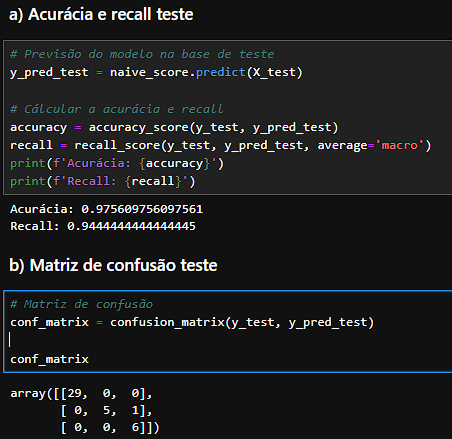

Ao comparar os resultados entre a Árvore de Decisão e o modelo Naive Bayes, observa-se que ambos apresentaram desempenho bastante elevado e muito semelhante na base de teste, com acurácia próxima de 98% e poucos erros nas matrizes de confusão. Enquanto a Árvore de Decisão apresentou um erro pontual na classe Alto, o Naive Bayes apresentou um erro na classe Médio, indicando que ambos os modelos possuem alta capacidade preditiva, com pequenas diferenças na distribuição dos erros entre as classes.

A principal diferença está no comportamento dos modelos: a Árvore de Decisão demonstrou melhor ajuste na base de treino (chegando a 100% de acurácia), o que pode indicar leve *overfitting*, enquanto o Naive Bayes apresentou desempenho mais consistente entre treino e teste.

Dessa forma, ambos os modelos se mostraram adequados ao problema, sendo a Árvore de Decisão ligeiramente superior em capacidade de ajuste, enquanto o Naive Bayes se destaca pela simplicidade e estabilidade.